Train class balance: [580 620]
Val   class balance: [147 153]
Epoch 1/5 | train loss 0.691 | val acc 0.510
Epoch 2/5 | train loss 0.682 | val acc 0.740
Epoch 3/5 | train loss 0.651 | val acc 0.700
Epoch 4/5 | train loss 0.584 | val acc 1.000
Epoch 5/5 | train loss 0.467 | val acc 0.927


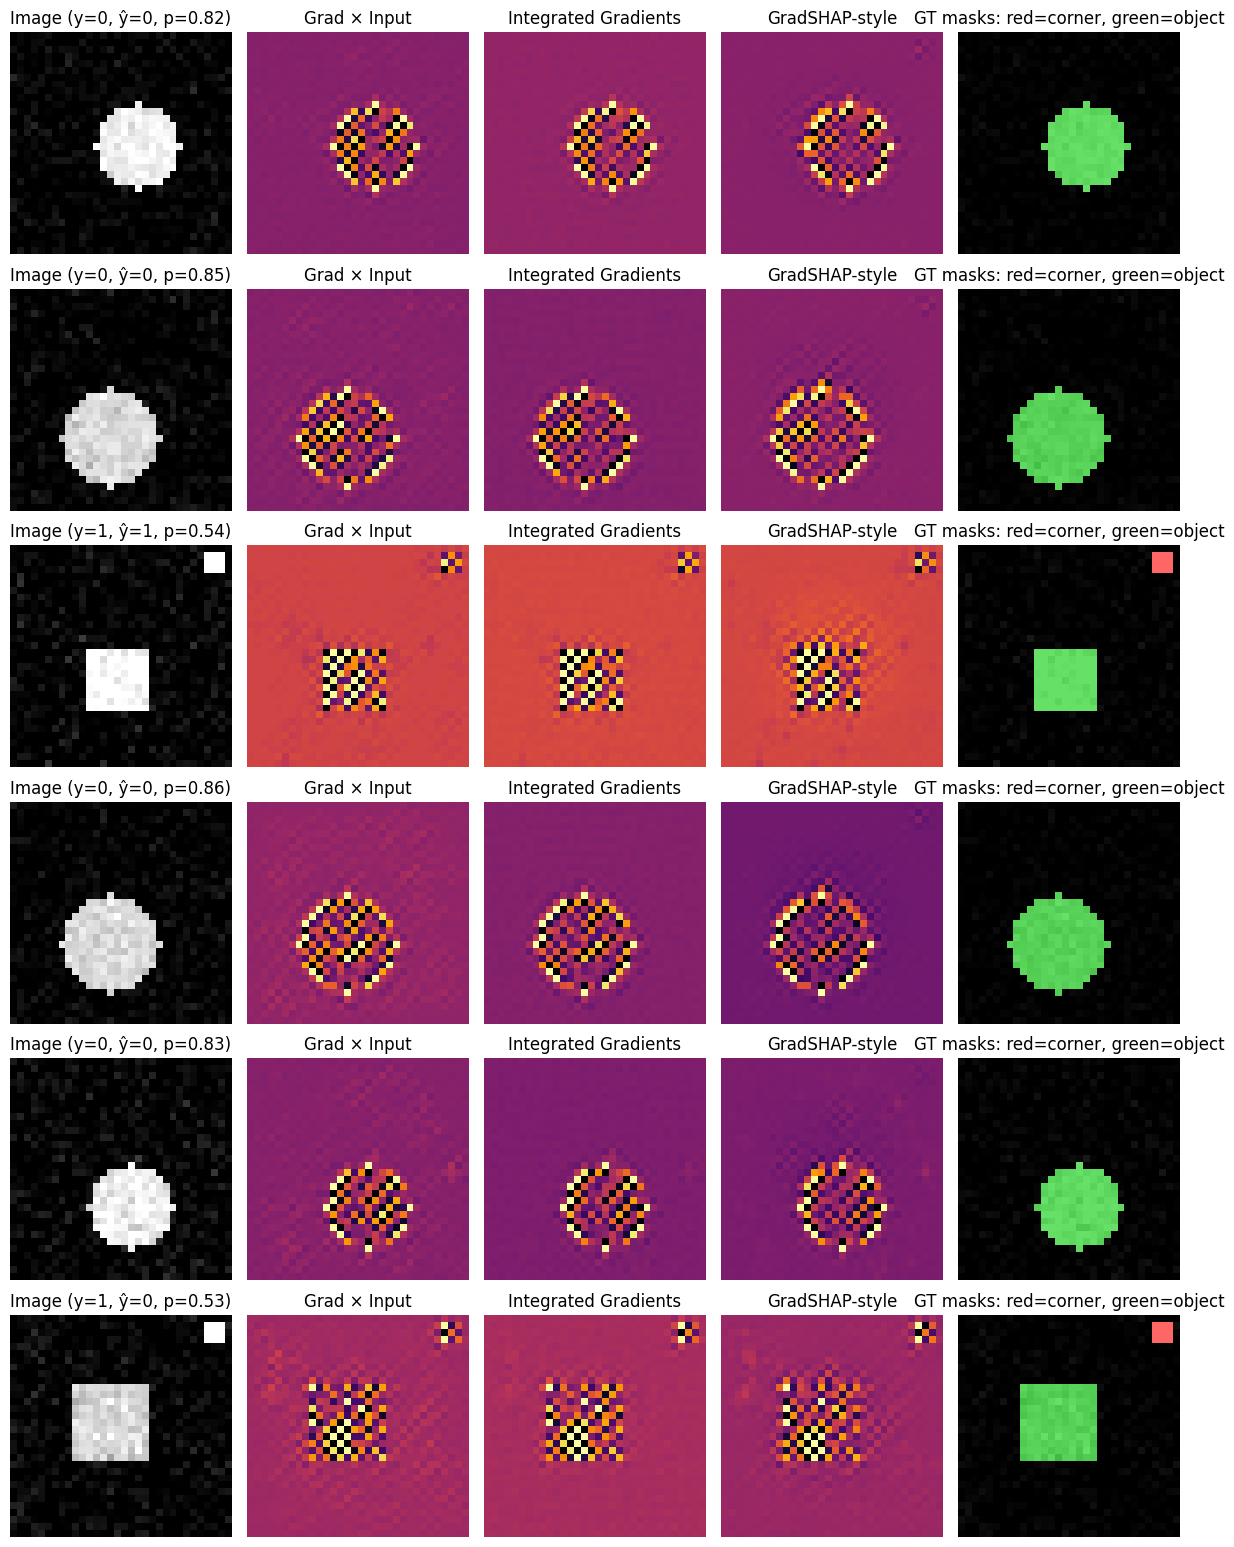

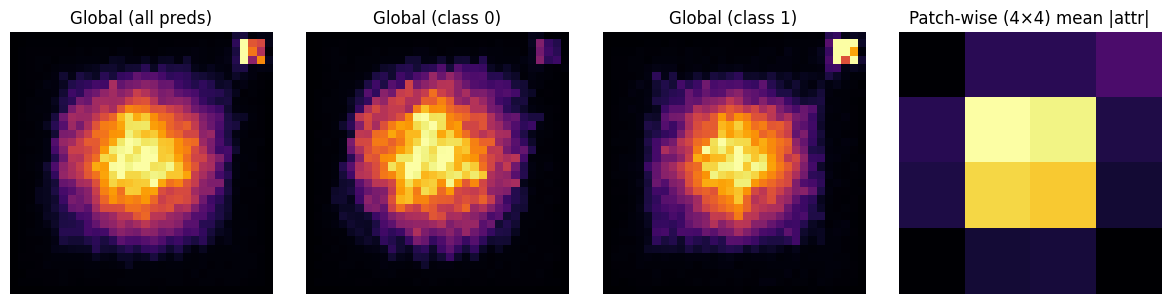

Top-10% attribution coverage (global average): {'obj': 0.7637254827085737, 'corner': 0.03372548986543637, 'other': 0.20254901762206848}


/var/folders/kn/8r9v1j3942jctw7h474j8tfw0000gn/T/ipykernel_73388/3265454675.py:267: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = float(np.trapz(curve, xs)) / max(1e-6, abs(base_logit))


Mean Deletion AUC (↓ better): -0.983
Mean Insertion AUC (↑ better): -3.780
Stability under LR flip (Spearman; higher is better): mean=0.511
Sanity check (rand weights vs trained) Spearman corr: -0.104 (should be low/near 0)


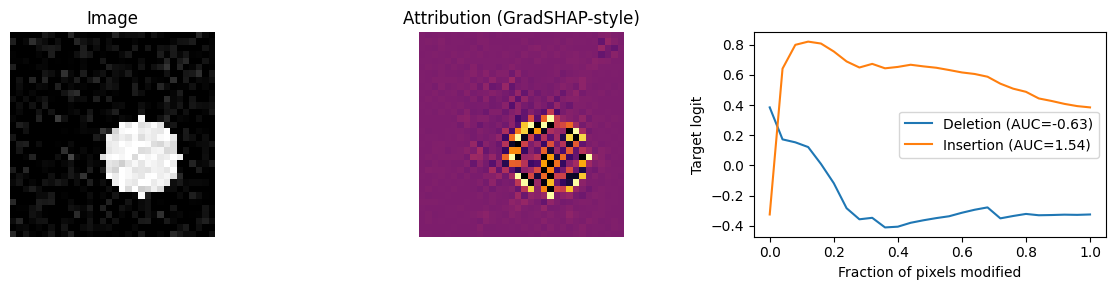

In [1]:
# === XAI on Images: Local & Global Attributions (Self-contained Demo) ============================
# This single cell builds a tiny synthetic dataset (images), trains a small CNN,
# explains predictions with three methods (Grad*Input, Integrated Gradients, GradientSHAP-style),
# aggregates to global conclusions, and evaluates explanation quality (faithfulness, stability).
#
# No external installs beyond PyTorch/Matplotlib/NumPy are needed.
# -----------------------------------------------------------------------------------------------

import math, random, os, copy
from dataclasses import dataclass
from typing import Tuple, List, Dict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------
# Reproducibility & device
# ------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1) Synthetic dataset generator
#    - Two classes: 0=circle, 1=square
#    - Spurious 'corner marker' shortcut present in 80% of class-1 images
#    - Returns image, label, object mask, corner mask
# ------------------------------

IMG_SZ = 32

def draw_circle_mask(cx, cy, r, sz=IMG_SZ):
    yy, xx = np.ogrid[:sz, :sz]
    return ((xx - cx)**2 + (yy - cy)**2) <= r*r

def draw_square_mask(cx, cy, half, sz=IMG_SZ):
    yy, xx = np.ogrid[:sz, :sz]
    return (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

def make_image(label:int, p_spurious=0.8) -> Tuple[np.ndarray, int, np.ndarray, np.ndarray]:
    """Create a (32x32) grayscale image with a circle (class 0) or square (class 1).
       Optionally adds a bright 3x3 corner marker (spurious feature) to top-right.
       Returns: image [H,W], label, object_mask [H,W], corner_mask [H,W].
    """
    img = np.zeros((IMG_SZ, IMG_SZ), dtype=np.float32)
    obj_mask = np.zeros_like(img, dtype=bool)
    corner_mask = np.zeros_like(img, dtype=bool)

    # Random centre within safe bounds
    cx = np.random.randint(10, 22)
    cy = np.random.randint(10, 22)

    if label == 0:
        r = np.random.randint(5, 8)
        obj_mask = draw_circle_mask(cx, cy, r)
    else:
        half = np.random.randint(4, 6)
        obj_mask = draw_square_mask(cx, cy, half)

    # Render object with soft edges
    img[obj_mask] = np.random.uniform(0.6, 0.9)
    img = img + 0.05*np.random.randn(*img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    # Add spurious corner marker for class 1 with probability p_spurious
    if (label == 1) and (np.random.rand() < p_spurious):
        corner_mask[1:4, -4:-1] = True
        img[corner_mask] = 1.0

    # Light normalisation
    img = (img - img.mean()) / (img.std() + 1e-6)
    img = np.clip(img, -3, 3)
    return img.astype(np.float32), label, obj_mask, corner_mask

def make_dataset(n:int) -> Dict[str, np.ndarray]:
    xs, ys, objms, cornms = [], [], [], []
    for _ in range(n):
        y = np.random.randint(0,2)
        x, y, obj, corn = make_image(y)
        xs.append(x); ys.append(y); objms.append(obj); cornms.append(corn)
    X = np.stack(xs)[..., None]                # [N,H,W,1]
    y = np.array(ys, dtype=np.int64)
    OM = np.stack(objms)                       # [N,H,W]
    CM = np.stack(cornms)                      # [N,H,W]
    return dict(X=X, y=y, obj_mask=OM, corner_mask=CM)

# ------------------------------
# 2) Tiny CNN
# ------------------------------
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                 # 16x16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),         # 1x1
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        h = self.net(x)                       # [B,64,1,1]
        h = h.flatten(1)                      # [B,64]
        logits = self.fc(h)                   # [B,2]
        return logits

# ------------------------------
# 3) Training helper
# ------------------------------
def train_model(model, train, val, epochs=5, lr=1e-3, batch=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(1, epochs+1):
        model.train()
        # mini-batches
        idx = np.random.permutation(len(train["X"]))
        losses = []
        for s in range(0, len(idx), batch):
            j = idx[s:s+batch]
            x = torch.from_numpy(train["X"][j].transpose(0,3,1,2)).to(DEVICE)  # NHWC->NCHW
            y = torch.from_numpy(train["y"][j]).to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = F.cross_entropy(logits, y)
            loss.backward(); opt.step()
            losses.append(loss.item())
        # quick val
        model.eval()
        with torch.no_grad():
            x = torch.from_numpy(val["X"].transpose(0,3,1,2)).to(DEVICE)
            y = torch.from_numpy(val["y"]).to(DEVICE)
            acc = (model(x).argmax(1)==y).float().mean().item()
        print(f"Epoch {ep}/{epochs} | train loss {np.mean(losses):.3f} | val acc {acc:.3f}")

# ------------------------------
# 4) Attribution methods
# ------------------------------
def grad_times_input(model: nn.Module, x: torch.Tensor, target: int) -> torch.Tensor:
    """Gradient × Input attribution on the logit for `target` class.
       x: [1,1,H,W] (requires_grad set inside)
       returns: [H,W] heatmap
    """
    model.eval()
    x = x.clone().detach().to(DEVICE).requires_grad_(True)
    logits = model(x)
    logit = logits[:, target].sum()
    logit.backward()
    at = x.grad * x
    at = at.detach().cpu().numpy()[0,0]
    return at

def integrated_gradients(model, x, target, baseline=None, steps=32, noise_sigma=0.0):
    """Integrated Gradients from baseline→x on the target logit.
       Optional small noise for smoothing. Returns [H,W].
    """
    model.eval()
    x = x.clone().detach().to(DEVICE)
    if baseline is None:
        baseline = torch.zeros_like(x)
    # accumulate gradients
    total = torch.zeros_like(x)
    for t in range(1, steps+1):
        alpha = t / steps
        xt = baseline + alpha * (x - baseline)
        if noise_sigma > 0:
            xt = xt + noise_sigma * torch.randn_like(xt)
        xt.requires_grad_(True)
        logit = model(xt)[:, target].sum()
        grads = torch.autograd.grad(logit, xt)[0]
        total = total + grads
    # average gradient and scale by (x - baseline)
    avg_grad = total / steps
    at = (x - baseline) * avg_grad
    return at.detach().cpu().numpy()[0,0]

def gradient_shap_style(model, x, target, baselines: List[torch.Tensor], nsamples=32, noise_sigma=0.1):
    """Approximate GradientSHAP: integrate gradients along random baselines
       with Gaussian noise. Returns [H,W].
    """
    model.eval()
    x = x.clone().detach().to(DEVICE)
    acc = torch.zeros_like(x)
    for _ in range(nsamples):
        b = baselines[np.random.randint(0, len(baselines))].to(DEVICE)
        alpha = np.random.rand()
        xt = b + alpha * (x - b) + noise_sigma * torch.randn_like(x)
        xt.requires_grad_(True)
        logit = model(xt)[:, target].sum()
        grad = torch.autograd.grad(logit, xt)[0]
        acc = acc + grad
    avg = acc / nsamples
    at = (x - torch.stack(baselines).mean(0).to(DEVICE)) * avg
    return at.detach().cpu().numpy()[0,0]

def occlusion_sensitivity(model, x, target, k=5, baseline_val=0.0):
    """Sliding-window occlusion: replace k×k patches with baseline and measure drop in target logit.
       Returns positive map where larger = more crucial.
    """
    model.eval()
    x = x.clone().detach().to(DEVICE)
    with torch.no_grad():
        base = model(x)[:, target].item()
    xnp = x.cpu().numpy()[0,0].copy()
    H, W = xnp.shape
    heat = np.zeros_like(xnp)
    for i in range(0, H, 1):
        for j in range(0, W, 1):
            ii = slice(max(0, i-k//2), min(H, i+k//2+1))
            jj = slice(max(0, j-k//2), min(W, j+k//2+1))
            patch = xnp.copy()
            patch[ii, jj] = baseline_val
            with torch.no_grad():
                y = torch.from_numpy(patch[None,None]).to(DEVICE)
                score = model(y)[:, target].item()
            heat[i, j] = max(0.0, base - score)  # importance by drop
    return heat

# Utility: normalise maps to [0,1] for display
def normalise01(a):
    a = a.astype(np.float32)
    lo, hi = np.percentile(a, 1), np.percentile(a, 99)
    if hi <= lo: hi = lo + 1e-6
    a = (a - lo) / (hi - lo)
    return np.clip(a, 0, 1)

# ------------------------------
# 5) Faithfulness metrics
# ------------------------------
def topk_mask_from_attribution(att: np.ndarray, k_frac: float) -> np.ndarray:
    """Binary mask for the top-k fraction of absolute attribution."""
    flat = np.abs(att).ravel()
    k = max(1, int(k_frac * flat.size))
    thresh = np.partition(flat, -k)[-k]
    return (np.abs(att) >= thresh)

def deletion_insertion_auc(model, x, target, att, steps=20, mode="deletion", baseline=0.0):
    """AUC of score vs fraction pixels changed, following the attribution ordering."""
    model.eval()
    x0 = x.clone().detach().to(DEVICE)
    with torch.no_grad():
        base_logit = model(x0)[:, target].item()
    H, W = att.shape
    order = np.argsort(-np.abs(att).ravel())  # top first
    area = H*W
    curve = []
    cur = x0.clone()
    for s in range(steps+1):
        frac = s/steps
        n = int(frac * area)
        idx = order[:n]
        canvas = cur.cpu().numpy()[0,0]
        if mode == "deletion":
            canvas = canvas.copy()
            canvas.ravel()[idx] = baseline
        else:  # insertion: start from baseline, add top features
            canvas = (np.ones_like(canvas)*baseline)
            canvas.ravel()[idx] = x0.cpu().numpy()[0,0].ravel()[idx]
        with torch.no_grad():
            y = torch.from_numpy(canvas[None,None]).to(DEVICE)
            score = model(y)[:, target].item()
        curve.append(score)
    # normalise AUC to [0,1] range using baseline score as reference
    xs = np.linspace(0,1,steps+1)
    auc = float(np.trapz(curve, xs)) / max(1e-6, abs(base_logit))
    return auc, (xs, curve)

# ------------------------------
# 6) Global aggregation helpers
# ------------------------------
def aggregate_global_abs(at_list: List[np.ndarray]) -> np.ndarray:
    """Mean absolute attribution across images."""
    stack = np.stack([np.abs(a) for a in at_list])
    return stack.mean(axis=0)

def aggregate_patchwise(at_list: List[np.ndarray], grid=4) -> np.ndarray:
    """Downsample attributions into a grid (e.g., 4x4) for simple global bar-heatmaps."""
    H, W = at_list[0].shape
    gh, gw = grid, grid
    ph, pw = H//gh, W//gw
    mats = []
    for a in at_list:
        M = np.zeros((gh, gw), dtype=np.float32)
        for i in range(gh):
            for j in range(gw):
                patch = a[i*ph:(i+1)*ph, j*pw:(j+1)*pw]
                M[i,j] = np.abs(patch).mean()
        mats.append(M)
    return np.stack(mats).mean(0)

# ------------------------------
# 7) End-to-end: build data, train, explain, evaluate
# ------------------------------

# 7a) data
N_TRAIN, N_VAL = 1200, 300
train = make_dataset(N_TRAIN)
val   = make_dataset(N_VAL)

# quick peek at class balance
print("Train class balance:", np.bincount(train["y"]))
print("Val   class balance:", np.bincount(val["y"]))

# 7b) model + training
model = TinyCNN().to(DEVICE)
train_model(model, train, val, epochs=5, lr=1e-3, batch=128)

# 7c) choose a few examples
def to_torch_img(xnp):  # [H,W] -> [1,1,H,W]
    return torch.from_numpy(xnp[None,None].astype(np.float32))

sample_ids = np.random.choice(len(val["X"]), size=6, replace=False)
samples = [(val["X"][i], val["y"][i], val["obj_mask"][i], val["corner_mask"][i]) for i in sample_ids]

# Baselines for GradientSHAP-style: (i) zeros, (ii) blurred/mean-ish image
def blur_like(x, k=5):
    # simple box blur
    from scipy.signal import convolve2d
    kern = np.ones((k,k), dtype=np.float32) / (k*k)
    return convolve2d(x, kern, mode="same", boundary="symm").astype(np.float32)
try:
    # Attempt blur; if SciPy not available, fall back to zeros-only baseline
    _ = blur_like(val["X"][0])
    BLURS_AVAILABLE = True
except Exception:
    BLURS_AVAILABLE = False

baselines = []
# zero baseline
baselines.append(torch.zeros(1,1,IMG_SZ,IMG_SZ))
# blurred baseline (if available)
if BLURS_AVAILABLE:
    bimg = np.stack([blur_like(val["X"][i][...,0]) for i in range(min(32, len(val["X"])))], axis=0).mean(0)
    baselines.append(to_torch_img(bimg))
else:
    # fallback: a constant mean image based on training set
    mean_img = train["X"][...,0].mean(0)
    baselines.append(to_torch_img(mean_img))

# 7d) Local explanations for a few images
fig, axes = plt.subplots(len(samples), 5, figsize=(12, 2.6*len(samples)))
axes = np.atleast_2d(axes)

local_maps_grad, local_maps_ig, local_maps_gshap = [], [], []

model.eval()
for r, (img, ytrue, objm, cornm) in enumerate(samples):
    xt = to_torch_img(img[...,0]).to(DEVICE)
    with torch.no_grad():
        logits = model(xt)
        yhat = int(logits.argmax(1).item())
        prob = float(F.softmax(logits,1)[0,yhat].item())

    # Local explanations (on predicted class)
    gxi = grad_times_input(model, xt, yhat)
    ig  = integrated_gradients(model, xt, yhat, baseline=baselines[0], steps=48, noise_sigma=0.0)
    gs  = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=32, noise_sigma=0.1)

    local_maps_grad.append(gxi); local_maps_ig.append(ig); local_maps_gshap.append(gs)

    # Plot row: image | Grad*Input | IntGrad | GradSHAP-approx | masks
    axes[r,0].imshow(img[...,0], cmap="gray"); axes[r,0].set_title(f"Image (y={ytrue}, ŷ={yhat}, p={prob:.2f})")
    axes[r,1].imshow(normalise01(gxi), cmap="inferno"); axes[r,1].set_title("Grad × Input")
    axes[r,2].imshow(normalise01(ig),  cmap="inferno"); axes[r,2].set_title("Integrated Gradients")
    axes[r,3].imshow(normalise01(gs),  cmap="inferno"); axes[r,3].set_title("GradSHAP-style")
    # masks: object (green) and corner (red) overlay
    mask_rgb = np.dstack([
        cornm.astype(float),                    # R
        objm.astype(float)*0.8,                # G
        np.zeros_like(objm, dtype=float)       # B
    ])
    axes[r,4].imshow(img[...,0], cmap="gray"); axes[r,4].imshow(mask_rgb, alpha=0.6)
    axes[r,4].set_title("GT masks: red=corner, green=object")
    for c in range(5): axes[r,c].axis("off")

plt.tight_layout(); plt.show()

# 7e) Global aggregation on the whole validation set
# We'll use the GradSHAP-style map for aggregation (generally smoother & robust).
def batch_explain(attrib="gshap", n=200):
    ids = np.random.choice(len(val["X"]), size=min(n, len(val["X"])), replace=False)
    maps_all, maps0, maps1 = [], [], []
    model.eval()
    for i in ids:
        xnp = val["X"][i][...,0]
        xt = to_torch_img(xnp).to(DEVICE)
        with torch.no_grad():
            yhat = int(model(xt).argmax(1).item())
        if attrib == "gshap":
            a = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=16, noise_sigma=0.1)
        elif attrib == "ig":
            a = integrated_gradients(model, xt, yhat, baseline=baselines[0], steps=32)
        else:
            a = grad_times_input(model, xt, yhat)
        maps_all.append(a)
        (maps0 if yhat==0 else maps1).append(a)
    return maps_all, maps0, maps1

maps_all, maps0, maps1 = batch_explain("gshap", n=200)

global_all = aggregate_global_abs(maps_all)
global_0   = aggregate_global_abs(maps0) if maps0 else np.zeros_like(global_all)
global_1   = aggregate_global_abs(maps1) if maps1 else np.zeros_like(global_all)
patch_heat = aggregate_patchwise(maps_all, grid=4)

fig, axs = plt.subplots(1,4, figsize=(12,3))
axs[0].imshow(normalise01(global_all), cmap="inferno"); axs[0].set_title("Global (all preds)")
axs[1].imshow(normalise01(global_0), cmap="inferno");   axs[1].set_title("Global (class 0)")
axs[2].imshow(normalise01(global_1), cmap="inferno");   axs[2].set_title("Global (class 1)")
im = axs[3].imshow(normalise01(patch_heat), cmap="inferno"); axs[3].set_title("Patch-wise (4×4) mean |attr|")
for a in axs: a.axis("off")
plt.tight_layout(); plt.show()

# 7f) Quantify reliance on object vs. corner (coverage)
def coverage(maps: List[np.ndarray], masks: Dict[str, np.ndarray], top_frac=0.1) -> Dict[str,float]:
    """Fraction of top-importance pixels that lie in each region."""
    obj_mask = masks["obj_mask"]; corner_mask = masks["corner_mask"]
    cov_obj, cov_corner, cov_other = [], [], []
    for k, att in enumerate(maps):
        top = topk_mask_from_attribution(att, top_frac)
        obj  = (top & obj_mask[k]).sum()
        corn = (top & corner_mask[k]).sum()
        other = top.sum() - obj - corn
        s = top.sum() + 1e-6
        cov_obj.append(obj/s); cov_corner.append(corn/s); cov_other.append(other/s)
    return {
        "obj": float(np.mean(cov_obj)),
        "corner": float(np.mean(cov_corner)),
        "other": float(np.mean(cov_other)),
    }

# Compute maps for all val items (predicted-class attributions)
maps_all_full = []
preds = []
for i in range(len(val["X"])):
    xnp = val["X"][i][...,0]
    xt = to_torch_img(xnp).to(DEVICE)
    with torch.no_grad():
        yhat = int(model(xt).argmax(1).item()); preds.append(yhat)
    a = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=8, noise_sigma=0.1)
    maps_all_full.append(a)

cov = coverage(maps_all_full, val, top_frac=0.1)
print("Top-10% attribution coverage (global average):", cov)

# 7g) Faithfulness: Deletion / Insertion AUC
subset = np.random.choice(len(val["X"]), size=32, replace=False)
del_aucs, ins_aucs = [], []
for i in subset:
    xnp = val["X"][i][...,0]; xt = to_torch_img(xnp).to(DEVICE)
    with torch.no_grad():
        yhat = int(model(xt).argmax(1).item())
    att = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=16, noise_sigma=0.1)
    d_auc, _ = deletion_insertion_auc(model, xt, yhat, att, steps=20, mode="deletion", baseline=0.0)
    i_auc, _ = deletion_insertion_auc(model, xt, yhat, att, steps=20, mode="insertion", baseline=0.0)
    del_aucs.append(d_auc); ins_aucs.append(i_auc)
print(f"Mean Deletion AUC (↓ better): {np.mean(del_aucs):.3f}")
print(f"Mean Insertion AUC (↑ better): {np.mean(ins_aucs):.3f}")

# 7h) Stability test: flip horizontally and compare maps
def flip_lr(x: np.ndarray) -> np.ndarray:
    return np.ascontiguousarray(x[:, ::-1])

stab_corrs = []
for i in subset[:16]:
    xnp = val["X"][i][...,0]
    xflip = flip_lr(xnp)
    xt = to_torch_img(xnp).to(DEVICE)
    xf = to_torch_img(xflip).to(DEVICE)
    with torch.no_grad():
        yhat = int(model(xt).argmax(1).item())
        yhat_f = int(model(xf).argmax(1).item())
    a = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=16)
    af = gradient_shap_style(model, xf, yhat_f, baselines=baselines, nsamples=16)
    # flip the map back for alignment
    af_unflipped = flip_lr(af)
    # Spearman-like rank correlation via numpy (approx: Pearson on ranks)
    from scipy.stats import spearmanr
    r, _ = spearmanr(a.ravel(), af_unflipped.ravel())
    stab_corrs.append(r)
print(f"Stability under LR flip (Spearman; higher is better): mean={np.nanmean(stab_corrs):.3f}")

# 7i) Sanity check: randomise weights -> explanations should collapse
model_rand = TinyCNN().to(DEVICE)
i = subset[0]
xnp = val["X"][i][...,0]; xt = to_torch_img(xnp).to(DEVICE)
with torch.no_grad(): yhat = int(model(xt).argmax(1).item())
a_good = gradient_shap_style(model, xt, yhat, baselines=baselines, nsamples=16)
with torch.no_grad(): yhat_r = int(model_rand(xt).argmax(1).item())
a_rand = gradient_shap_style(model_rand, xt, yhat_r, baselines=baselines, nsamples=16)

from scipy.stats import spearmanr
r_san, _ = spearmanr(a_good.ravel(), a_rand.ravel())
print(f"Sanity check (rand weights vs trained) Spearman corr: {r_san:.3f} (should be low/near 0)")

# 7j) Visual summary for one example (deletion/insertion curves)
att = a_good
d_auc, (xs_d, ys_d) = deletion_insertion_auc(model, xt, yhat, att, steps=25, mode="deletion")
i_auc, (xs_i, ys_i) = deletion_insertion_auc(model, xt, yhat, att, steps=25, mode="insertion")

fig, axs = plt.subplots(1,3, figsize=(12,3))
axs[0].imshow(xnp, cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
axs[1].imshow(normalise01(att), cmap="inferno"); axs[1].set_title("Attribution (GradSHAP-style)"); axs[1].axis("off")
axs[2].plot(xs_d, ys_d, label=f"Deletion (AUC={d_auc:.2f})")
axs[2].plot(xs_i, ys_i, label=f"Insertion (AUC={i_auc:.2f})")
axs[2].set_xlabel("Fraction of pixels modified"); axs[2].set_ylabel("Target logit")
axs[2].legend()
plt.tight_layout(); plt.show()

# ------------------------------
# Notes for reporting (copy into your write-up):
# • Explainer: GradientSHAP-style (random baselines + noisy IG), target = predicted class logit.
# • Baselines: zeros and blurred/mean image. Show sensitivity across baselines if desired.
# • Global aggregation: mean absolute attribution; class-wise maps; 4×4 patch importances.
# • Faithfulness: Deletion/Insertion AUC (lower deletion, higher insertion are better).
# • Stability: correlation under horizontal flips.
# • Sanity: explanations degrade when weights are randomised.
# • Limitations: baseline dependence; feature dependence (pixels not independent); correlations are not causation—validate with deletion/insertion and (if you like) ROAR/KAR retraining.
# ============================== END ============================================================
